In [2]:
from CXRO_Tools import Filter_Transmission
import numpy as np
import matplotlib.pyplot as plt
import random
from Quantum_Efficiency import QE_Interpolated_Function
import lmfit

In [3]:
def do_QE_fit(x, y, min, max, step, Si_thickness, C_thickness, SiO2_thickness, Fe_thickness):
    QE_model = lmfit.Model(QE_Interpolated_Function)


    QE_params = QE_model.make_params(
        min = min,
        max = max,
        step = step,
        Si_thickness = Si_thickness,
        C_thickness = C_thickness,
        SiO2_thickness = SiO2_thickness,
        Fe_thickness = Fe_thickness
        )

    QE_params['min'].vary = False
    QE_params['max'].vary = False
    QE_params['step'].vary = False
    QE_params['Si_thickness'].vary = True
    QE_params['C_thickness'].vary = True
    QE_params['SiO2_thickness'].vary = True
    QE_params['Fe_thickness'].vary = True

    QE_params['Si_thickness'].set(min=2)
    QE_params['C_thickness'].set(min=0.001)
    QE_params['SiO2_thickness'].set(min=0.001)
    QE_params['Fe_thickness'].set(min=0.001)

    result = QE_model.fit(data = y, params = QE_params, x=x)
    return result

Set Values

In [4]:
min = 30.
max = 2000.
step = 100.
Si_thickness = 5
C_thickness = 0.1
SiO2_thickness = 0.1
Fe_thickness = 0.05

Generate Test Data

In [5]:
# Range of datapoints with QE values directly taken from model
datapoints = range(int(min), int(max), int((max-min)/step))
QE_from_expected_function = QE_Interpolated_Function(x=datapoints, min=min, max=max, Si_thickness=Si_thickness, C_thickness=C_thickness, SiO2_thickness=SiO2_thickness, Fe_thickness=Fe_thickness, step=step) #QE values from interpolated function

# Delete half of datapoints
test_indices = random.sample(range(len(datapoints)), (int(len(datapoints)/2)))
test_indices.sort()
trimmed_energies = [datapoints[i] for i in test_indices]
trimmed_QE = [QE_from_expected_function[i] for i in test_indices]

# Add up to n% random error to QE
percent_error = 15
test_QE = []
for i in trimmed_QE:
    sign_generator = random.random()
    error_sign = 1 if sign_generator >= .5 else -1
    error = random.random() * percent_error/100 * error_sign
    adjusted_QE = i * (1+error)
    test_QE.append(adjusted_QE)

fit_initial_params = {
    "Si": 6,
    "C": 0.3,
    "SiO2": 0.25,
    "Fe": 0.15
}

Try Fit

In [6]:
x, y = trimmed_energies, test_QE
result = do_QE_fit(x, y, Si_thickness=fit_initial_params["Si"], C_thickness=fit_initial_params["C"], SiO2_thickness=fit_initial_params["C"], Fe_thickness=fit_initial_params["Fe"], min=min, max=max, step=step)
print(result.fit_report())

[[Model]]
    Model(QE_Interpolated_Function)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 133
    # data points      = 52
    # variables        = 4
    chi-square         = 0.07872216
    reduced chi-square = 0.00164005
    Akaike info crit   = -329.639864
    Bayesian info crit = -321.834889
    R-squared          = 0.95665903
[[Variables]]
    min:             30 (fixed)
    max:             2000 (fixed)
    Si_thickness:    5.04603190 +/- 0.08751203 (1.73%) (init = 6)
    C_thickness:     0.10524543 +/- 0.00525451 (4.99%) (init = 0.3)
    SiO2_thickness:  0.07392407 +/- 0.00431145 (5.83%) (init = 0.3)
    Fe_thickness:    0.05438351 +/- 0.00166200 (3.06%) (init = 0.15)
    step:            100 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(C_thickness, SiO2_thickness)  = -0.4906
    C(SiO2_thickness, Fe_thickness) = -0.1930
    C(Si_thickness, Fe_thickness)   = +0.1712
    C(C_thickness, Fe_thickness)    = -0.1274


Plot

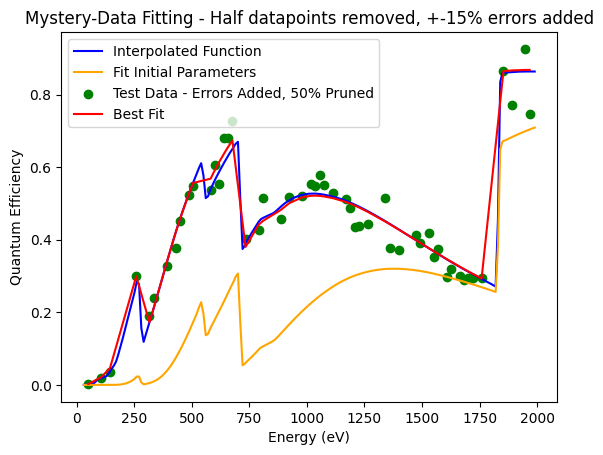

In [11]:
finerange = range(int(min), int(max), 10)
plt.plot(finerange, QE_Interpolated_Function(x=finerange, min=min, max=max, Si_thickness=Si_thickness, C_thickness=C_thickness, SiO2_thickness=SiO2_thickness, Fe_thickness=Fe_thickness, step=step), label="Interpolated Function", color='blue')
plt.plot(finerange, QE_Interpolated_Function(x=finerange, Si_thickness=fit_initial_params["Si"], C_thickness=fit_initial_params["C"], SiO2_thickness=fit_initial_params["C"], Fe_thickness=fit_initial_params["Fe"], min=min, max=max, step=step), label="Fit Initial Parameters", color='orange')
#plt.scatter(datapoints, QE_from_expected_function, label="Datapoints from original function", color='blue')
#plt.scatter(trimmed_energies, trimmed_QE, label="Trimmed Data", color='lightblue')
plt.scatter(trimmed_energies, test_QE, label="Test Data - Errors Added, 50% Pruned", color='green')
plt.plot(trimmed_energies, result.best_fit, label="Best Fit", color='red')
plt.legend()
plt.title(f"Mystery-Data Fitting - Half datapoints removed, +-{percent_error}% errors added")
plt.xlabel("Energy (eV)")
plt.ylabel("Quantum Efficiency")
plt.show()

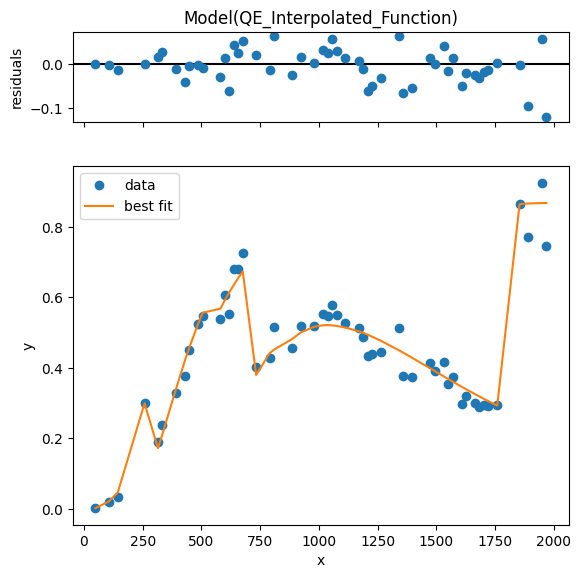

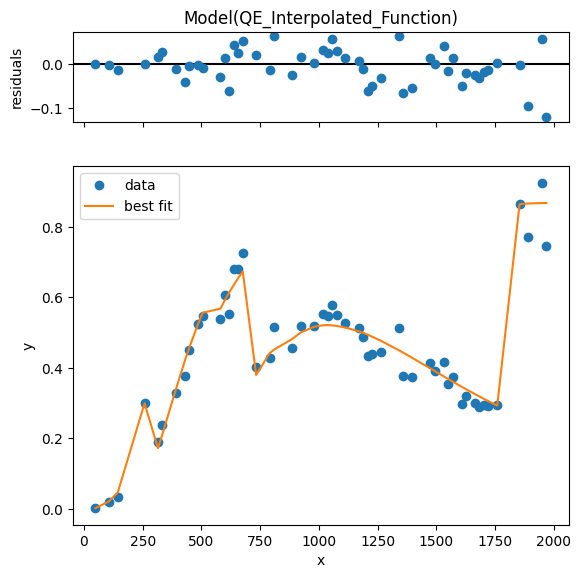

In [8]:
result.plot()